## 📈 Pair Trading Strategy

Pair trading is a market-neutral quantitative trading strategy that seeks to exploit temporary price deviations between two historically related assets. Instead of predicting the absolute direction of individual asset prices, this approach focuses on the relative movement between a pair of securities.

The core idea is based on the assumption that certain asset pairs—such as companies in the same sector—tend to move together over time due to shared economic factors. When this relationship temporarily diverges, a trading opportunity arises. The strategy involves taking opposite positions in the two assets: going long on the undervalued asset and short on the overvalued one, with the expectation that their prices will revert to their historical equilibrium.

## 🧠 Why Pair Trading Works

The effectiveness of pair trading can be understood through the concept of **cointegration driven by common nonstationary factors**, as discussed in *“Pairs Trading: Performance of a Relative-Value Arbitrage Rule.”*

In financial markets, asset prices are often influenced by **shared underlying economic forces** such as interest rates, sector performance, macroeconomic conditions, or overall market sentiment. These forces are typically **nonstationary**, meaning they evolve over time and introduce trends in asset prices.

A general representation of this idea is:

$$
p_{it} = \sum_{l=1}^{k} \beta_{il} p_{lt} + \epsilon_{it}, \quad k < n
$$

where:

* $p_{it}$ : price of asset *i* at time *t*
* $p_{lt}$ : common nonstationary factors affecting multiple assets
* $\beta_{il}$ : sensitivity of asset *i* to factor *l*
* $ \epsilon_{it}$ : idiosyncratic (asset-specific) noise

This equation shows that each asset price is composed of:

1. **Common nonstationary components** (shared across assets)
2. **Idiosyncratic noise** (unique to each asset)

---

### 🔗 Cointegration and Mean Reversion

Even though individual asset prices are nonstationary, multiple assets exposed to the same factors will move together. This implies that there exist **linear combinations of prices that eliminate the common factors**.

In other words, for some vector ( a ):

$
z_t = a^\top p_t
$

the resulting spread ( z_t ) is **stationary (mean-reverting)**.

This is the essence of **cointegration**.

---

### 📈 Why This Creates a Trading Opportunity

If two assets share the same underlying drivers:

* Their prices may drift over time due to common trends
* But their **relative difference remains stable**

Any deviation from this equilibrium is caused by:

* short-term noise
* liquidity imbalances
* delayed reactions to information

These deviations are **temporary** and expected to revert.

## 📊 Correlation vs Cointegration

Understanding the difference between correlation and cointegration is essential for building a robust pair trading strategy.

---

### 🔹 Correlation

Correlation measures the **linear relationship** between two variables. It indicates how strongly two asset prices move together over time.

The Pearson correlation coefficient is given by:

$$
\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

where:
- $\text{Cov}(X, Y)$ = covariance between $X$ and $Y$
- $\sigma_X, \sigma_Y$ = standard deviations of $X$ and $Y$

#### Key Properties:
- $\rho = 1$ → perfect positive correlation  
- $\rho = -1$ → perfect negative correlation  
- $\rho = 0$ → no linear relationship  

#### ⚠️ Limitation:
Correlation only captures **short-term co-movement** and can be misleading for nonstationary data. Two unrelated trending time series can appear highly correlated (spurious correlation).

---

### 🔹 Cointegration

Cointegration is a stronger concept than correlation. It applies to **nonstationary time series** that share a **long-term equilibrium relationship**.

Two series $X_t$ and $Y_t$ are said to be cointegrated if:
- Individually, they are nonstationary  
- A linear combination of them is stationary  

This can be written as:

$$
z_t = X_t - \beta Y_t
$$

If $z_t$ is stationary (mean-reverting), then $X_t$ and $Y_t$ are cointegrated.

---

### 🔹 Factor-Based Interpretation

Asset prices are often driven by common nonstationary factors:

$$
p_{it} = \sum_{l=1}^{k} \beta_{il} p_{lt} + e_{it}, \quad k < n
$$

where:
- $p_{it}$ = price of asset $i$
- $p_{lt}$ = common factors
- $\beta_{il}$ = factor loading
- $e_{it}$ = idiosyncratic noise

If two assets share the same underlying factors, a suitable linear combination can eliminate these common components, leaving a **stationary residual (spread)**.

---

### 🔥 Key Difference

| Concept        | Correlation                          | Cointegration                          |
|----------------|--------------------------------------|----------------------------------------|
| Type           | Short-term relationship              | Long-term equilibrium                  |
| Data           | Works on stationary or nonstationary | Requires nonstationary series          |
| Stability      | Not stable over time                 | Stable long-term relationship          |
| Use in trading | Weak signal                          | Strong foundation for pair trading     |

---

### 🧠 Intuition

- Correlation → “Do they move together right now?”  
- Cointegration → “Are they tied together in the long run?”  

Pair trading relies on **cointegration**, not just correlation, because it ensures that deviations between asset prices are **temporary and mean-reverting**.

## 📥 Data Source

The data used in this project is obtained using the `yfinance` library, which provides convenient access to historical market data from Yahoo Finance.

We specifically use **daily closing prices** for all selected assets. The closing price is chosen because it reflects the final consensus value of the asset at the end of each trading day and is commonly used in quantitative finance for analysis and modeling.


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import seaborn as sns
from itertools import combinations

## 📥 Data Collection and Preprocessing

In this step, we download historical price data for a selected set of stocks using the `yfinance` library.

- A list of ticker symbols is defined, representing major companies across different sectors (technology, energy, finance, and consumer goods).
- Historical data is fetched for the specified time period (2013–2015).
- From the downloaded dataset, only the **closing prices** are extracted, as they represent the final traded price of each asset for the day.
- Any missing values are removed to ensure that all time series are properly aligned for further analysis.

This cleaned dataset serves as the foundation for computing returns, correlations, and identifying potential pairs for trading.

In [ ]:
tickers = [
    "MSFT","AAPL","GOOGL","AMZN",
    "NVDA","PEP","KO",
    "V","MA", "XOM", "CVX"
]
data = yf.download(tickers, start="2013-01-01",end = "2015-01-01")["Close"]
data = data.dropna()

/tmp/ipykernel_136/1586534943.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2013-01-01",end = "2015-01-01")["Close"]
[*********************100%***********************]  11 of 11 completed


## 📊 Correlation Matrix Visualization

To identify potential pairs for trading, we begin by analyzing the **correlation between asset returns**. Correlation helps us understand how strongly two assets move together in the short term.

In this step, we compute the **daily returns** of each asset and then construct a **correlation matrix**. This matrix provides pairwise correlation values between all assets in the dataset.

The correlation matrix is then visualized using a **heatmap**, where:
- Warm colors (red) indicate **high positive correlation**
- Cool colors (blue) indicate **negative correlation**
- Values close to zero indicate weak or no linear relationship

This visualization allows us to quickly identify highly correlated asset pairs, which can serve as initial candidates for further analysis using **cointegration tests**.

⚠️ Note: High correlation alone does not guarantee a valid pair trading opportunity. It is only used as a **preliminary filtering step**, and must be followed by cointegration analysis to confirm a stable long-term relationship.

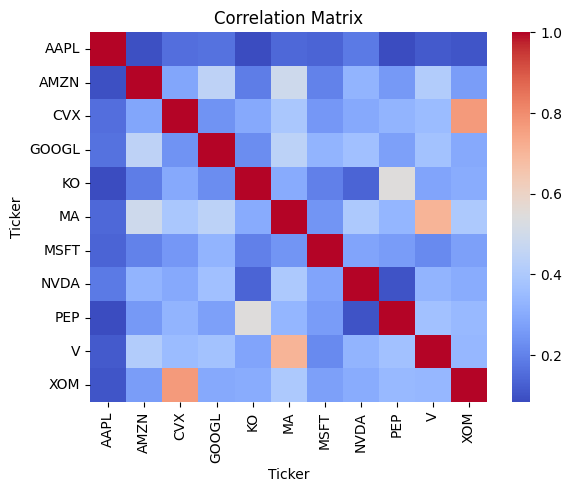

In [ ]:
returns = data.pct_change().dropna()
corr_matrix = returns.corr()
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 🔍 Candidate Pair Selection (Correlation Filter)

In this step, we generate all possible pairs of assets and filter them based on their correlation.

- First, all unique combinations of asset pairs are created.
- For each pair, the correlation between their **daily returns** is computed.
- Only pairs with correlation greater than **0.5** are selected as candidate pairs.

This step serves as a **preliminary filtering stage**, reducing the search space to pairs that exhibit a reasonable degree of co-movement. These candidate pairs are then further tested for **cointegration**, which is a stronger requirement for pair trading.

⚠️ Note: Correlation alone is not sufficient for pair trading. It only indicates short-term similarity and must be followed by statistical tests for long-term relationships.

In [ ]:
pairs = list(combinations(data.columns, 2))
candidate_pairs = []

for s1, s2 in pairs:

    corr = returns[s1].corr(returns[s2])

    if corr > 0.5:
        candidate_pairs.append((s1, s2))


## 🧪 Cointegration Testing (Engle-Granger Test)

After identifying candidate pairs based on correlation, we perform a **cointegration test** to verify whether the relationship between two assets is stable in the long run.

For each candidate pair, we apply the Engle-Granger cointegration test:

- The test evaluates whether a linear combination of the two price series is **stationary**
- It returns:
  - **test statistic (score)**
  - **p-value**
  - critical values (ignored here)

---

### 🔹 Understanding the p-value

The **p-value** helps us decide whether two assets are cointegrated.

- **Null Hypothesis ($H_0$):** The two series are *not cointegrated* (no stable long-term relationship)  
- **Alternative Hypothesis ($H_1$):** The two series are *cointegrated* (they share a stable relationship)

#### Interpretation:
- If **p-value < 0.05**:
  - Reject the null hypothesis  
  - The pair is likely **cointegrated**  
  - ✅ Suitable for pair trading  

- If **p-value ≥ 0.05**:
  - Fail to reject the null  
  - No evidence of cointegration  
  - ❌ Not suitable  

---

### 🔹 What does this mean intuitively?

A low p-value indicates that:

> “It is very unlikely that the observed relationship between these two price series occurred by random chance.”

In other words, the spread between the two assets is likely **mean-reverting**, which is the key requirement for a pair trading strategy.

---

### 🔹 Sorting Cointegrated Pairs

After identifying cointegrated pairs, we sort them by p-value:

- Lower p-value → stronger evidence of cointegration  
- Higher priority for trading  

---

### ⚠️ Important Note

- Cointegration is sensitive to the chosen time period  
- A pair that is cointegrated in the past may not remain so in the future  
- Always validate results using out-of-sample testing  

---

### 🧠 Summary

- Correlation → short-term relationship  
- Cointegration → long-term equilibrium  
- p-value → confidence in that equilibrium  

Pair trading relies on selecting pairs with **low p-values**, ensuring that deviations from equilibrium are likely to be temporary and exploitable.

In [ ]:
coint_pairs = []

for s1, s2 in candidate_pairs:

    score, pvalue, _ = coint(data[s1], data[s2])

    if pvalue < 0.05:
        coint_pairs.append((s1, s2, pvalue))
coint_pairs.sort(key=lambda x: x[2])
coint_pairs


[('KO', 'PEP', np.float64(0.018774816628133198))]